<a href="https://colab.research.google.com/github/WilliamBertolotto/Projeto-Genaration/blob/main/Aula_Estatistica_Inferencial_com_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
library(ggplot2) # biblioteca para printar gráficos
install.packages("forecast") # demora pra rodar a célula. É a instalação do pacote
library(forecast)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



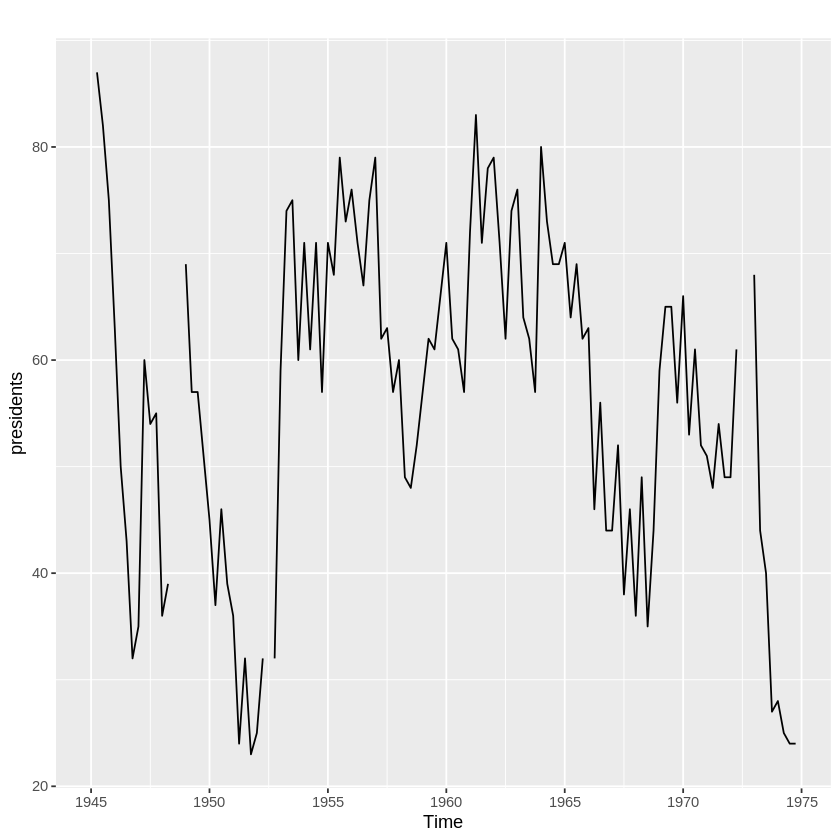

In [ ]:
# teste de Hipotese
# H_0 : os dados estão normalmente distribuídos
# H_1 : os dados não têm distribuição normal | os dados tem outra distribuição
# usaremos o teste de shapiro
# alpha = 0,05

#help(presidents) # informações sobre o pacote de dados
#print(presidents) # "NA" = dados ausentes (NULL)
autoplot(presidents) # dados/informações no tempo -> série temporal


	Shapiro-Wilk normality test

data:  presidents
W = 0.96757, p-value = 0.007226


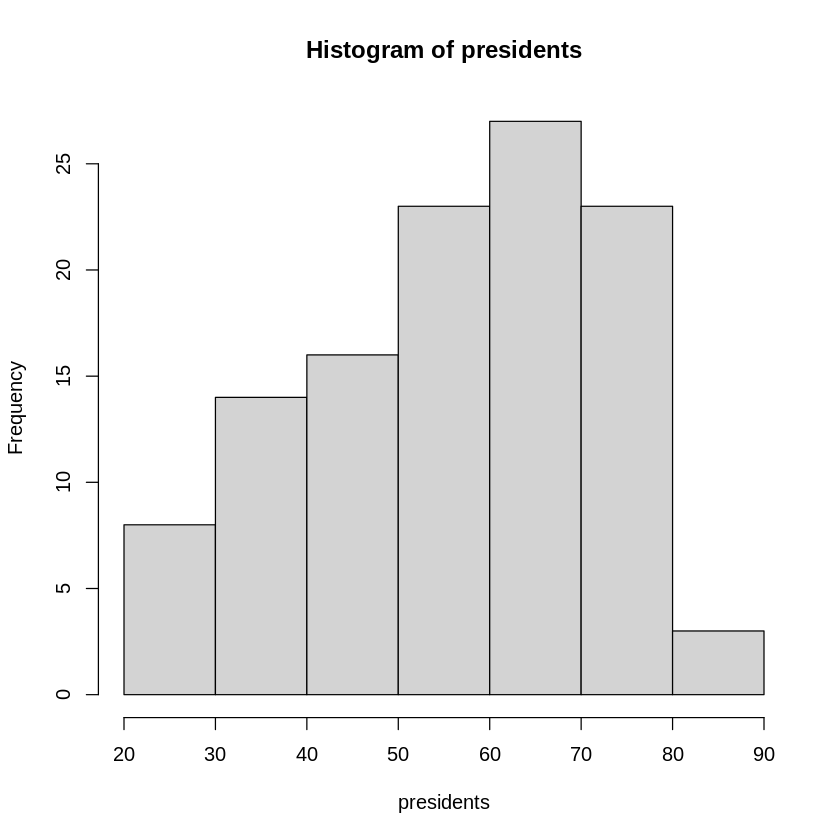

In [ ]:
# teste de Hipotese
# H_0 : os dados estão normalmente distribuídos
# H_1 : os dados não têm distribuição normal | os dados tem outra distribuição
# usaremos o teste de shapiro
# alpha = 0,05

shapiro.test(presidents)
hist(presidents)


	Ljung-Box test

data:  Residuals from ARIMA(1,0,0)(0,0,1)[4] with non-zero mean
Q* = 10.085, df = 6, p-value = 0.1211

Model df: 2.   Total lags used: 8



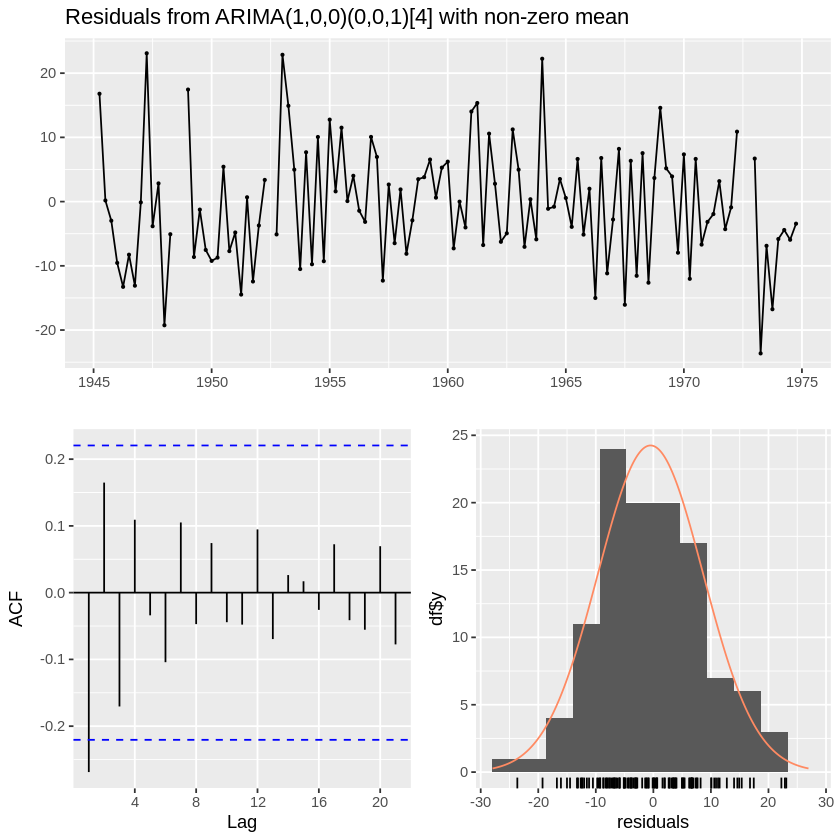

In [ ]:
# vamos construir o modelo (ARIMA)
# mas vamos olhar para os resíduos
modelo = auto.arima(presidents)
checkresiduals(modelo)
#autoplot(modelo$residuals)
# H_0 : os dados são normalmente distribuidos
#shapiro.test(modelo$residuals)
#hist(modelo$residuals)
#acf(modelo$residuals, na.action = na.pass) # funcao de autocorrelação


,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.4556157,8.933293,7.288359,-3.820994,14.07848,0.6006549,-0.08015857,NA
Test set,-16.8350576,24.141668,21.227623,-66.885853,73.65289,1.7494303,0.54824479,4.794904


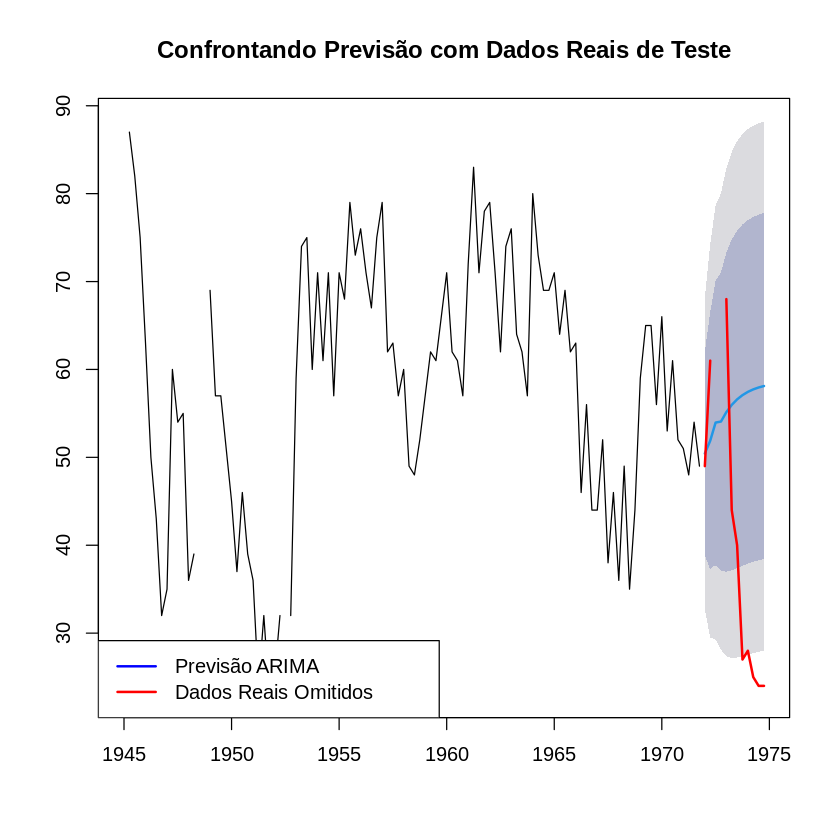

In [ ]:
# hold out do modelo (treino e teste)
# ou seja, vamos dividir a base em dois conjuntos (treino e teste)

# 1. Separar a base em Treino (1945 a 1971) e Teste (1972 a 1974)
dados_treino <- window(presidents, end=c(1971, 4))
dados_teste  <- window(presidents, start=c(1972, 1))

# 2. Ajustar o auto.arima apenas nos dados de treino
modelo_treino <- auto.arima(dados_treino)

# 3. Prever os próximos 12 trimestres (3 anos)
predicao_futura <- forecast(modelo_treino, h=12)

# 4. Confrontar graficamente a previsão (e intervalos de confiança) com os dados reais de teste
plot(predicao_futura, main="Confrontando Previsão com Dados Reais de Teste")
lines(dados_teste, col="red", lwd=2) # Adiciona a linha real de teste em vermelho
legend("bottomleft", legend=c("Previsão ARIMA", "Dados Reais Omitidos"), col=c("blue", "red"), lty=1, lwd=2)

# 5. Calcular a acurácia exata comparando o previsto com o teste real
accuracy(predicao_futura, dados_teste)
